In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
%matplotlib widget

In [3]:
# Import the raw spectra
data_path = Path(r'.')
fig_path = Path(r'./figures')

files = [
    '01_oro1_Valence_He-I_2026-06-17__14h18m07s',
    '03_oro1_Valence_He-I_2026-06-17__14h43m05s',
    '04_oro1_Valence_He-I_2026-06-17__14h47m50s',
    '05_oro1_Valence_He-I_2026-06-17__16h10m11s_alternative',
    '05_oro1_Valence_He-I_2026-06-17__16h10m11s',
    '06_oro1_Valence_He-I_2026-06-17__16h16m57s_alternative',
    '06_oro1_Valence_He-I_2026-06-17__16h16m57s',
    '07_oro1_Valence_He-I_2026-06-17__16h26m09s_alternative',
    '07_oro1_Valence_He-I_2026-06-17__16h26m09s',
    '08_oro1_Valence_He-I_2026-06-17__16h50m34s',
    '09_oro1_Valence_He-I_2026-06-17__16h55m13s',
    '10_oro1_backup_2026-06-17__18h04m26s',
]

# Load all data
def load_xps(filepath):
    """Load a fixXPS-exported .txt file into a dict of arrays."""
    data = np.genfromtxt(filepath, names=True)
    return {name: data[name] for name in data.dtype.names}

spectra = []   # spectra[i] = {'file_name_1': dict, 'file_name_2': dict, ...}
for i in range(len(files)):
    spectra.append(load_xps(data_path / f'{files[i]}.txt'))

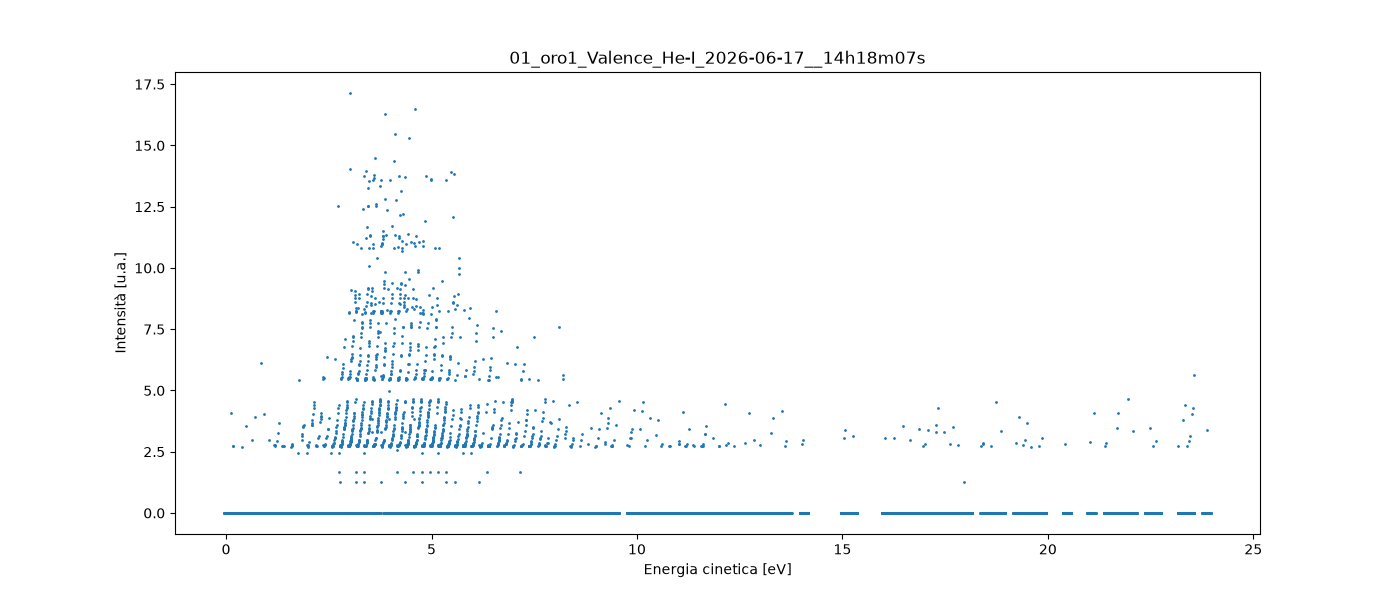

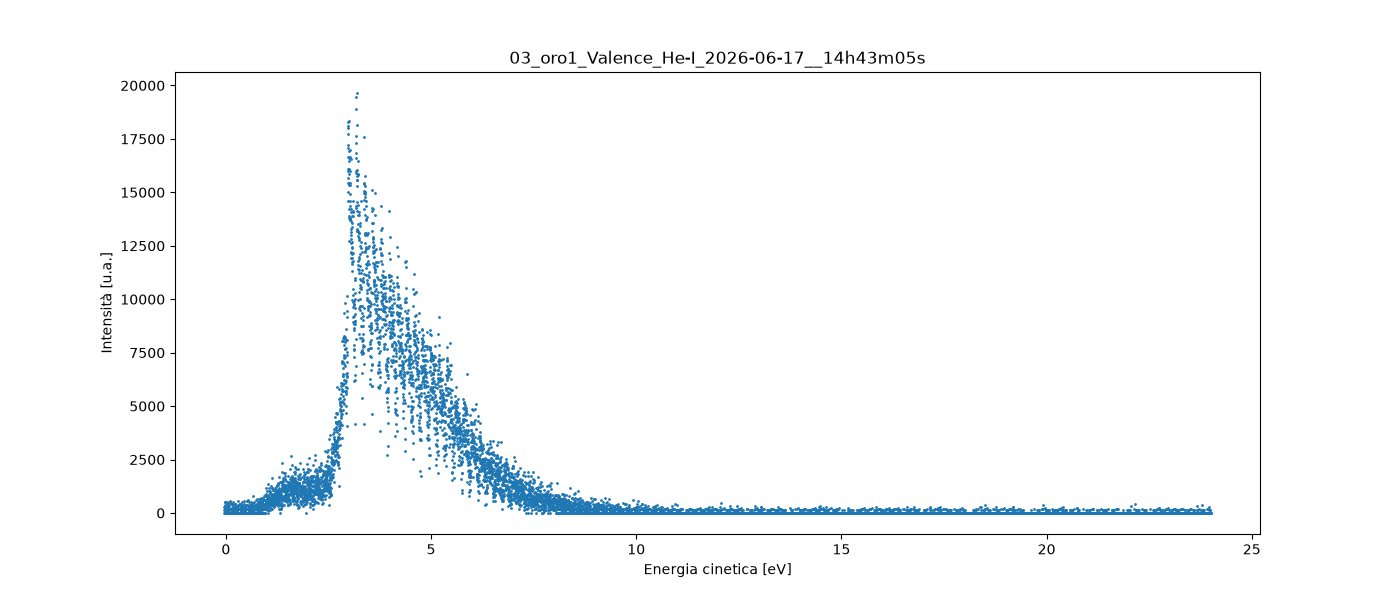

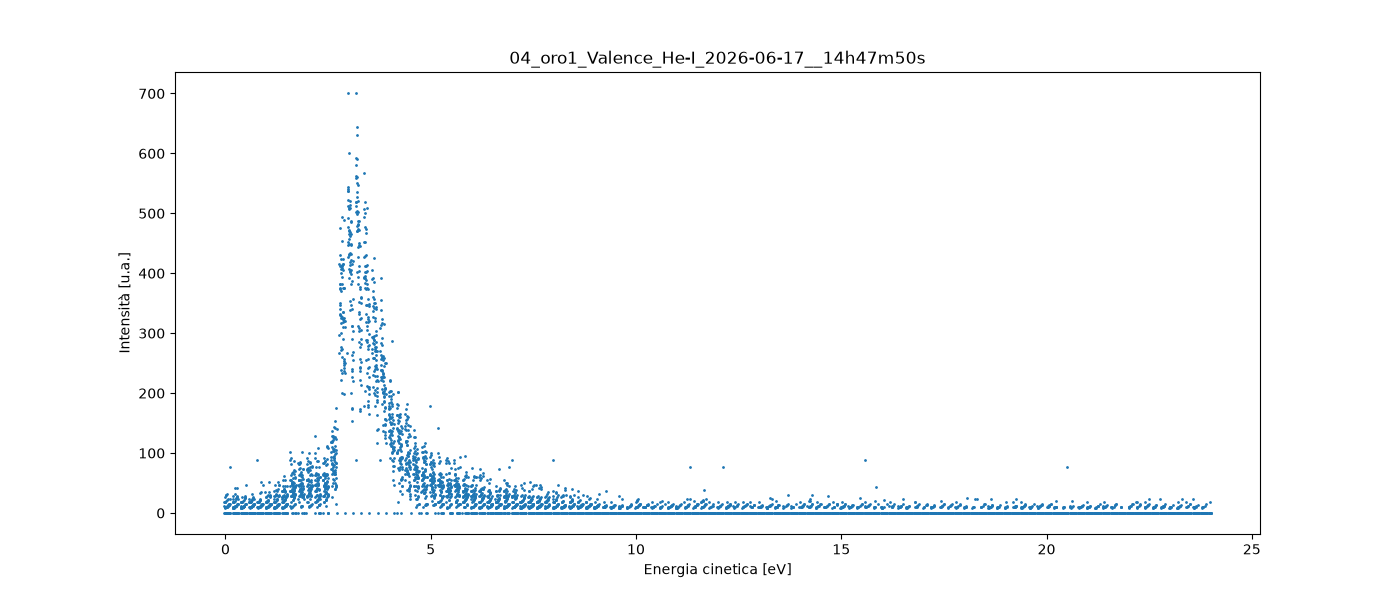

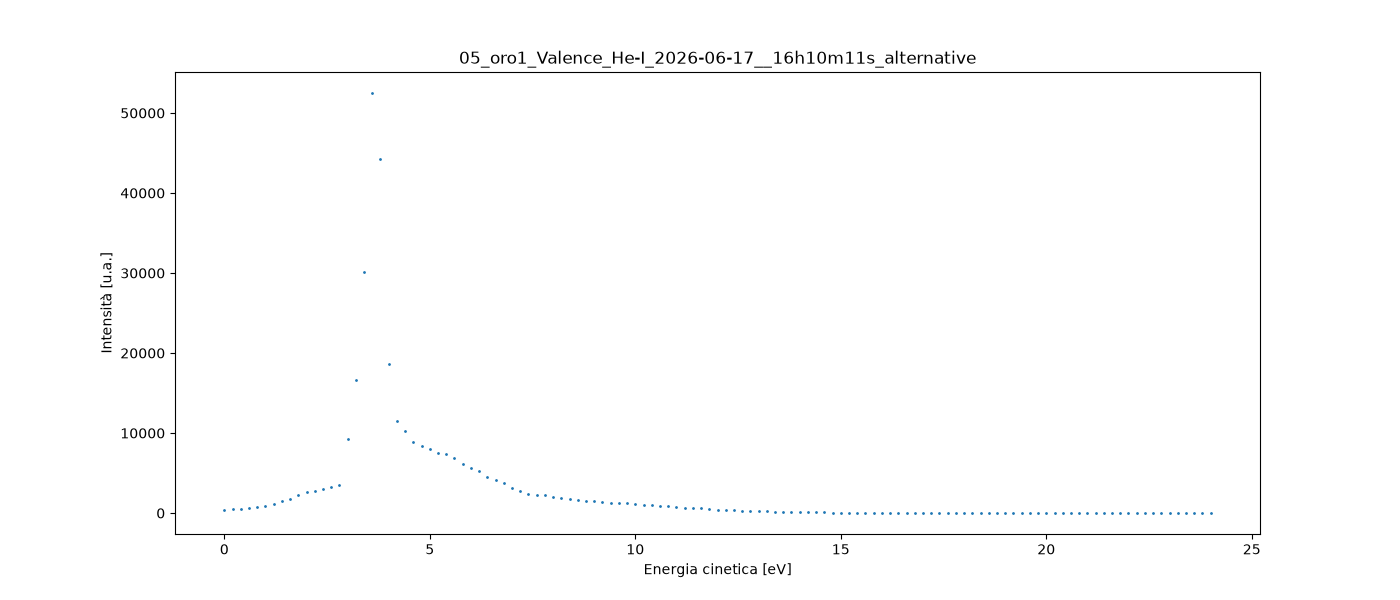

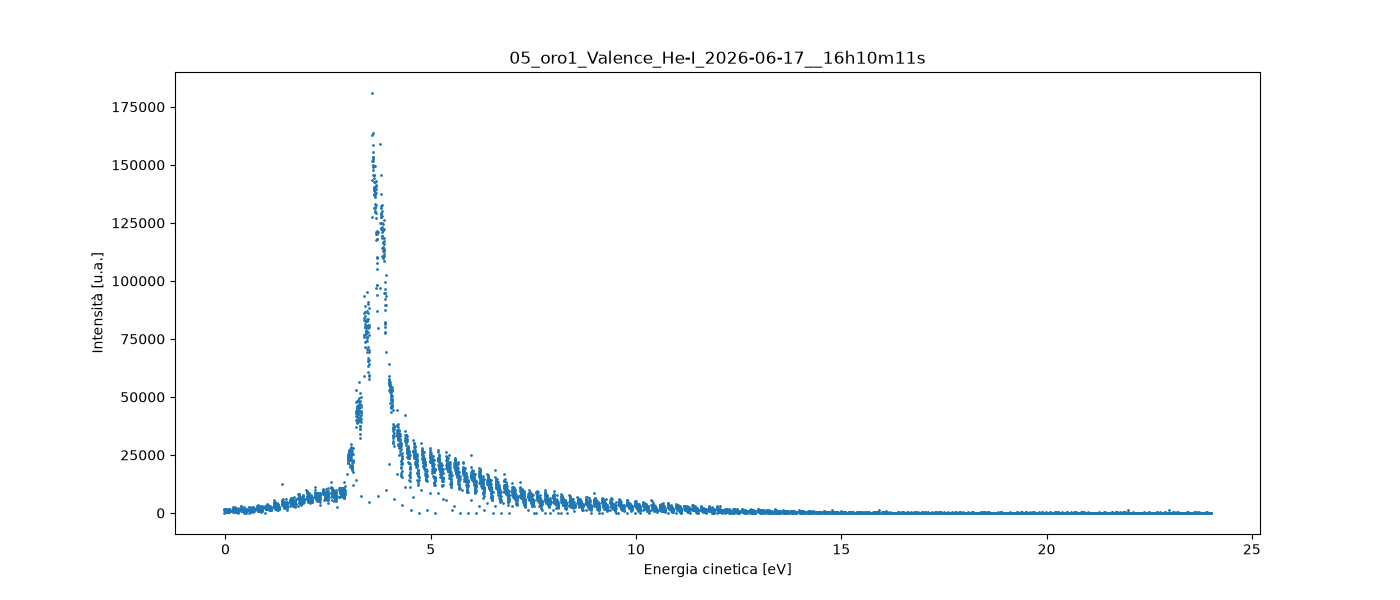

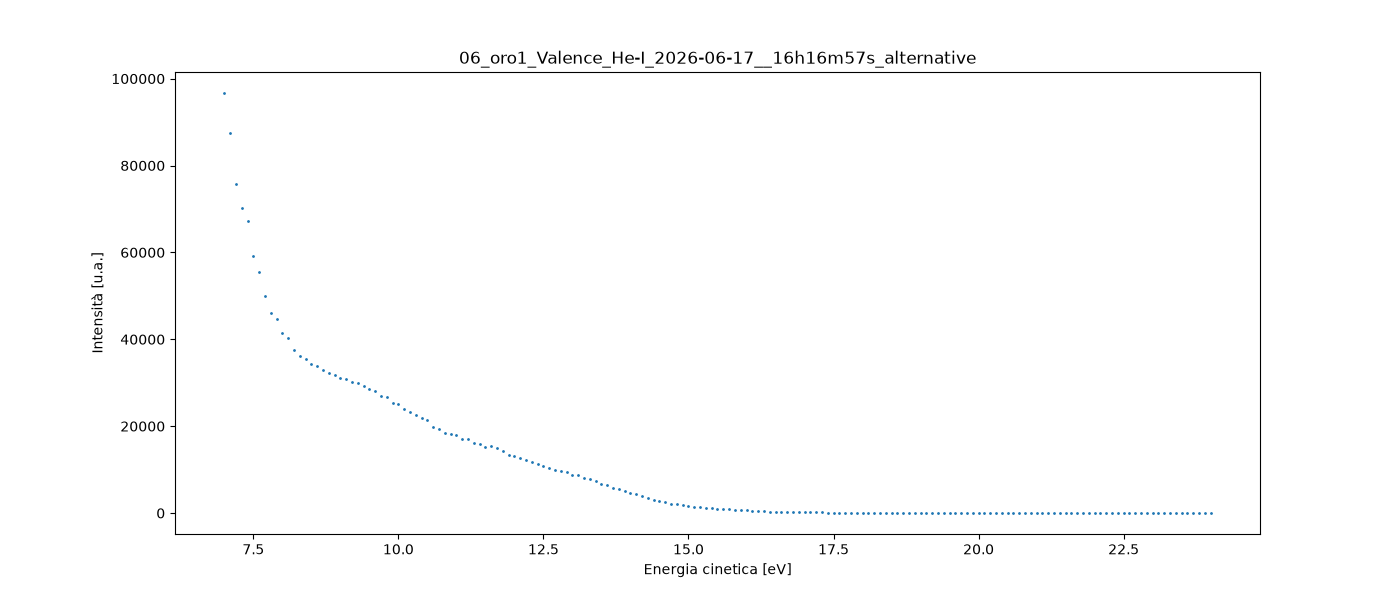

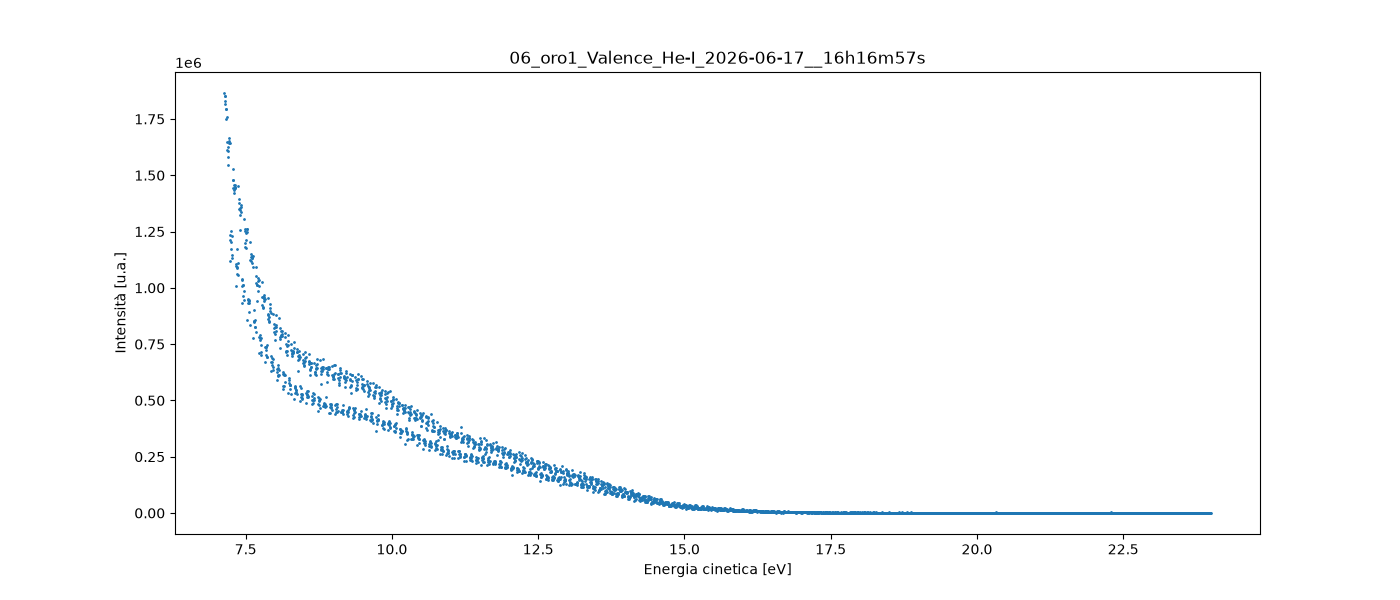

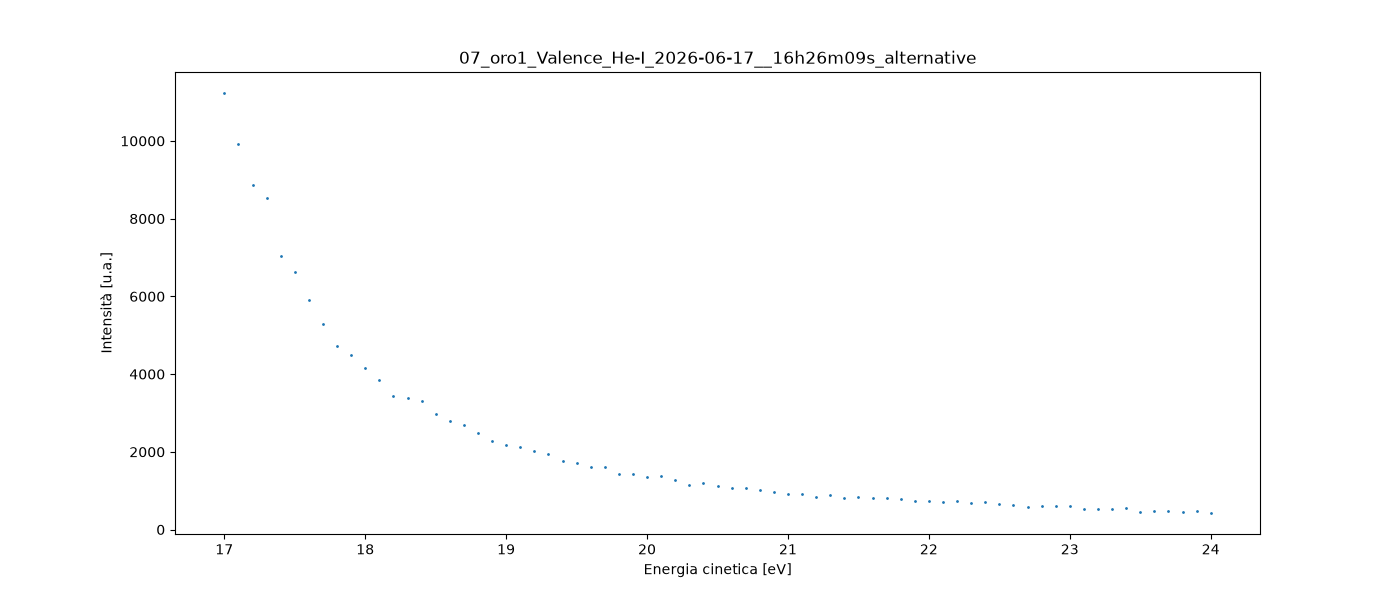

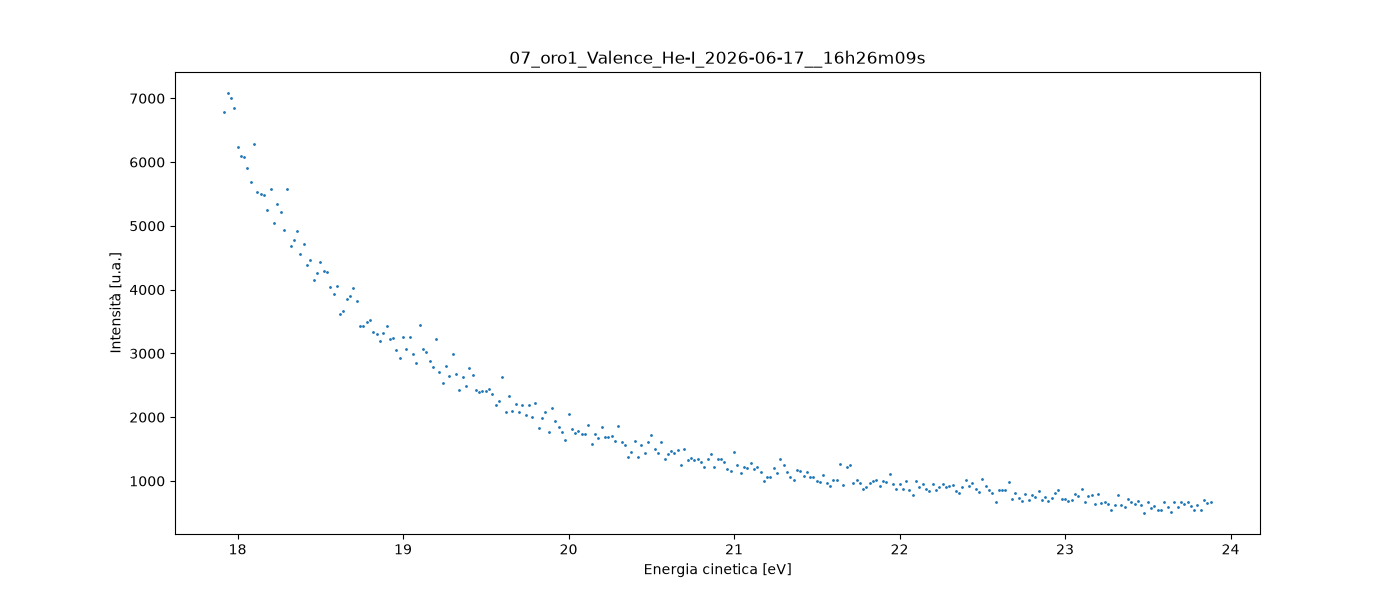

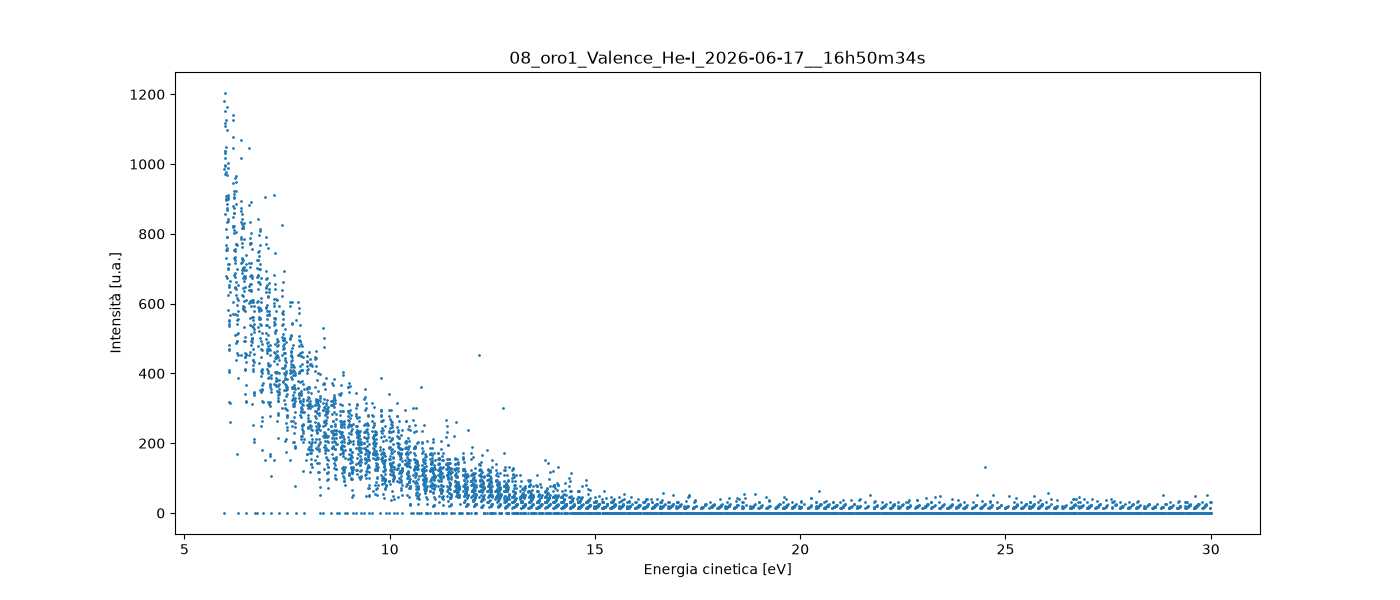

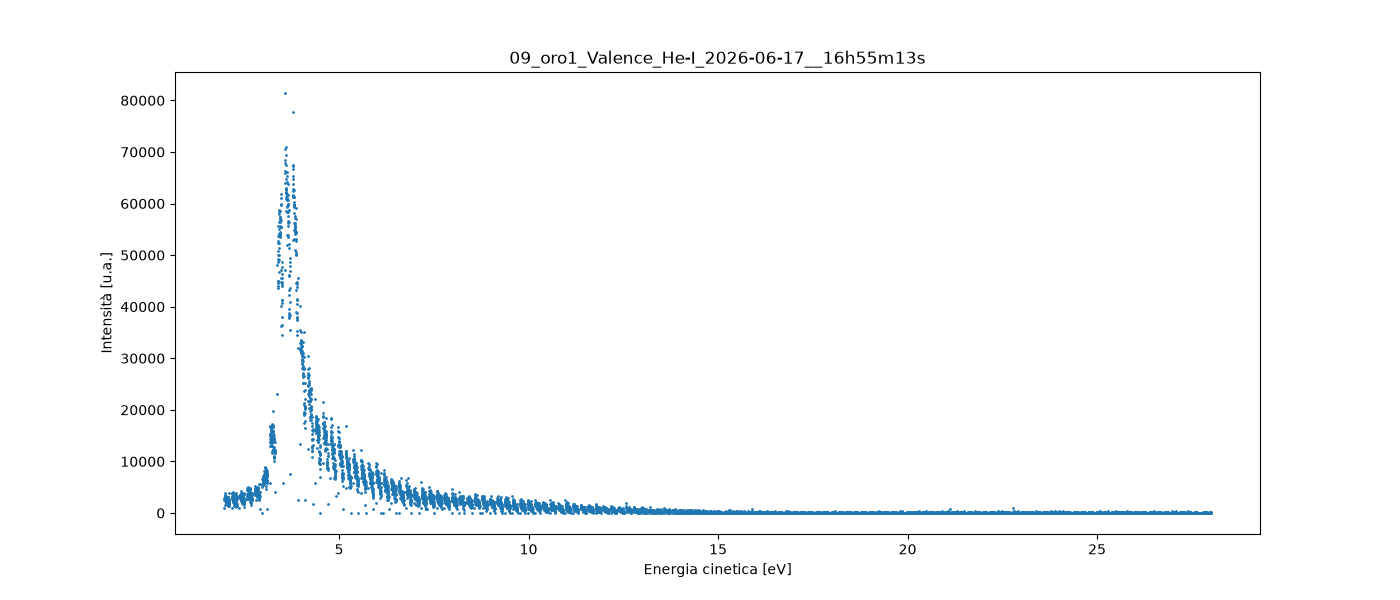

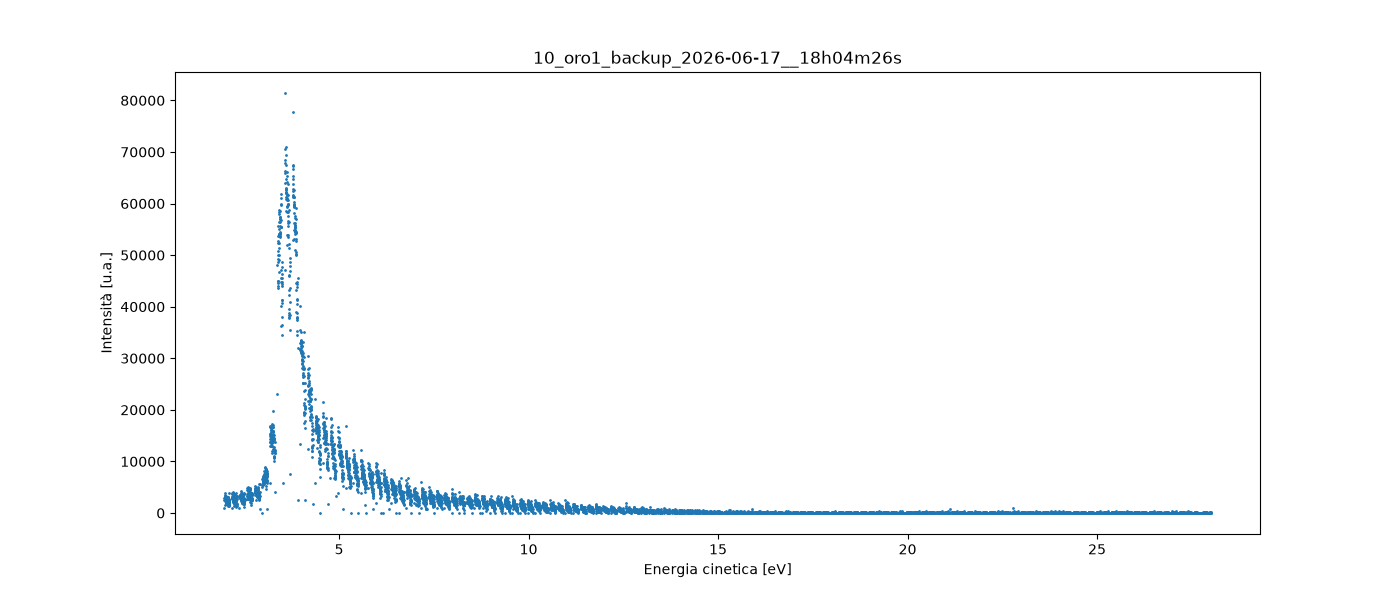

In [4]:
# Plot scatter of Energia cinetica vs. counts for each imported file
fig_path.mkdir(parents=True, exist_ok=True)

for i in range(len(files)):
    s = spectra[i]
    fig, ax = plt.subplots(figsize=(14,6))
    if i == 3 or i == 5 or i == 7:
        ax.scatter(s['KE_eV'], s['hits_counts'], s=1)
    else:
        ax.scatter(s['KE_eV'], s['counts'], s=1)
    ax.set_xlabel('Energia cinetica [eV]')
    ax.set_ylabel('Intensità [u.a.]')
    ax.set_title(files[i])
    fig.savefig(fig_path / f'{files[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()

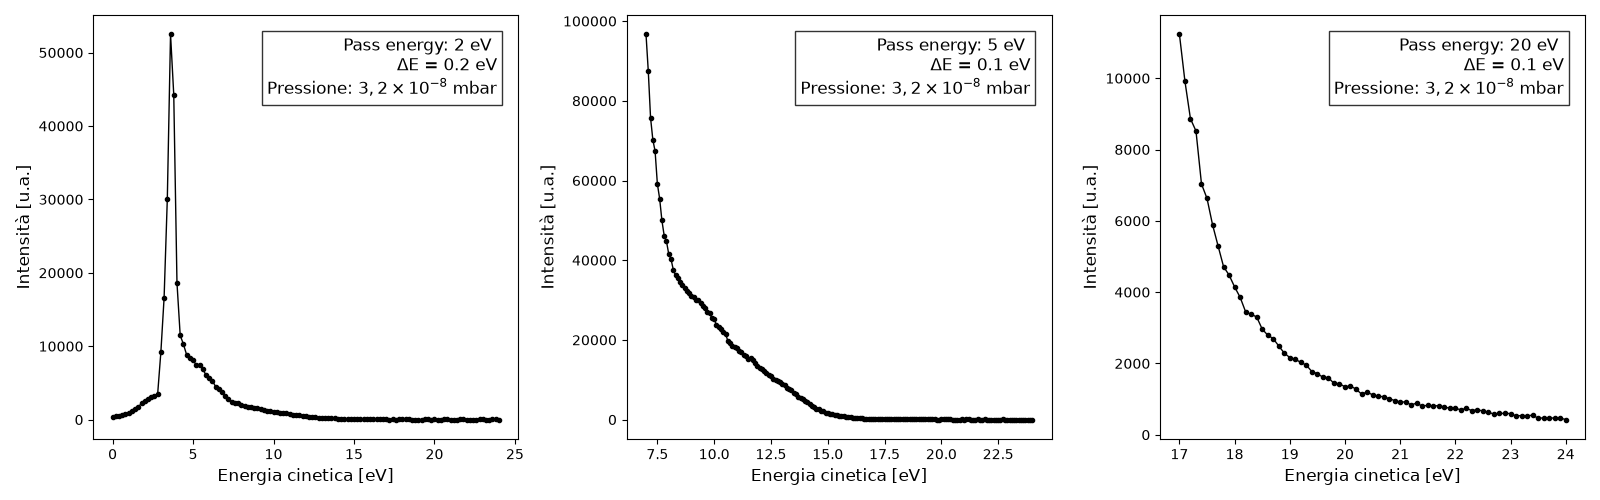

In [7]:
from cProfile import label


full = spectra[3]
zoom = spectra[5]
zoom_2 = spectra[7]

indices = [3, 5, 7]
data_list = [full, zoom, zoom_2]
pass_energies = [2, 5, 20]
delta_E = [0.2, 0.1, 0.1]

# # Scatter plot the alternative raw spectra
# mkr_size = 3
# mkr_color = 'black'
# fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# for i, (a, data, idx) in enumerate(zip(ax, data_list, indices)):
#     a.scatter(data['KE_eV'], data['hits_counts'], color=mkr_color, s=mkr_size)
#     a.set_xlabel('Energia cinetica [eV]')
#     a.set_ylabel('Intensità [u.a.]')
#     # a.set_title(files[idx])

# fig.tight_layout(h_pad=3)
# fig.savefig(fig_path / '05_06_07_oro1_valence_He-I_scatter_presentazione.png', dpi=300, bbox_inches='tight')

# # Save each subplot as a separate file
# for a, idx in zip(ax, indices):
#     extent = a.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
#     fig.savefig(fig_path / f'{files[idx]}_scatter_presentazione.png', dpi=300, bbox_inches=extent)

# plt.show()


# Line plot the alternative raw spectra
line = 1
line_color = 'black'
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

for i, (a, data, idx, pass_energy, delta_e) in enumerate(zip(ax, data_list, indices, pass_energies, delta_E)):
    a.plot(data['KE_eV'], data['hits_counts'], color=line_color, linewidth=line, marker=".")
    a.set_xlabel('Energia cinetica [eV]', fontsize=12)
    a.set_ylabel('Intensità [u.a.]', fontsize=12)
    a.text(0.95, 0.95, f'Pass energy: {pass_energy} eV \n' + r'$\Delta$' + f'E = {delta_e} eV' + '\n' + r'Pressione: $3,2 \times 10^{-8}$ mbar',
            transform=a.transAxes,
            fontsize=12,
            # fontweight='bold',
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.8))

fig.tight_layout(h_pad=3)
fig.savefig(fig_path / '05_06_07_oro1_valence_He-I_plot_presentazione.png', dpi=300, bbox_inches='tight')
plt.show()


for data, idx, pass_energy, delta_e in zip(data_list, indices, pass_energies, delta_E):
    fig_single, ax_single = plt.subplots(figsize=(16/3, 5))
    ax_single.plot(data['KE_eV'], data['hits_counts'], color=line_color, linewidth=line, marker=".")
    ax_single.set_xlabel('Energia cinetica [eV]', fontsize=12)
    ax_single.set_ylabel('Intensità [u.a.]', fontsize=12)
    ax_single.text(0.95, 0.95, f'Pass energy: {pass_energy} eV \n' + r'$\Delta$' + f'E = {delta_e} eV' + '\n' + r'Pressione: $3,2 \times 10^{-8}$ mbar',
                   transform=ax_single.transAxes,
                   fontsize=12,
                   # fontweight='bold',
                   verticalalignment='top',
                   horizontalalignment='right',
                   bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.8))
    fig_single.tight_layout()
    fig_single.savefig(fig_path / f'{files[idx]}_plot_presentazione.png', dpi=300, bbox_inches='tight')
    plt.close(fig_single)